In [1]:
from helpers.load import *
from helpers.select_scenario import select_scenario
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
scenario_folder_air = Path(os.path.abspath('')) / 'logs' / 'unified' / 'air'
scenario_folder_freshwater = Path(os.path.abspath('')) / 'logs' / 'unified' / 'freshwater'

In [3]:
def load_scenario_aggregate_df(scenario_folder, loader_function):
    agg_dfs = []
    for config_folder in sorted([folder for folder in scenario_folder.iterdir() if folder.is_dir()]):
        temp_df = loader_function(config_folder)
        temp_df['Config'] = config_folder.name
        agg_dfs.append(temp_df)
    
    return pd.concat(agg_dfs).reset_index(drop=True)

phy_tx_begin_freshwater = load_scenario_aggregate_df(scenario_folder_freshwater, load_phy_tx_begin)
phy_rx_end_freshwater = load_scenario_aggregate_df(scenario_folder_freshwater, load_phy_rx_end)

phy_tx_begin_air = load_scenario_aggregate_df(scenario_folder_air, load_phy_tx_begin)
phy_rx_end_air = load_scenario_aggregate_df(scenario_folder_air, load_phy_rx_end)

In [4]:
# Add a distance column to phy tx begin using SourceNodeX, SourceNodeY, SourceNodeZ, DestinationNodeX, DestinationNodeY, DestinationNodeZ
phy_tx_begin_freshwater['Distance'] = phy_tx_begin_freshwater.apply(lambda row: np.sqrt((row['SourceNodeX'] - row['DestinationNodeX'])**2 + (row['SourceNodeY'] - row['DestinationNodeY'])**2 + (row['SourceNodeZ'] - row['DestinationNodeZ'])**2), axis=1)
phy_tx_begin_air['Distance'] = phy_tx_begin_air.apply(lambda row: np.sqrt((row['SourceNodeX'] - row['DestinationNodeX'])**2 + (row['SourceNodeY'] - row['DestinationNodeY'])**2 + (row['SourceNodeZ'] - row['DestinationNodeZ'])**2), axis=1)

# Create a new df with the number of packets sent at each distance
phy_tx_begin_freshwater_distance = phy_tx_begin_freshwater[
            (phy_tx_begin_freshwater['SourceNodeType'] == 'STA') & 
            (phy_tx_begin_freshwater['DestinationNodeType'] == 'AP') #&
            #(phy_tx_begin_freshwater['PacketSize'] >= 150) # Filter out handshake/ACK packets
            ].groupby('Distance').size().reset_index(name='PacketCount')

phy_tx_begin_air_distance = phy_tx_begin_air[
            (phy_tx_begin_air['SourceNodeType'] == 'STA') & 
            (phy_tx_begin_air['DestinationNodeType'] == 'AP') #&
            #(phy_tx_begin_air['PacketSize'] >= 150) # Filter out handshake/ACK packets
            ].groupby('Distance').size().reset_index(name='PacketCount')

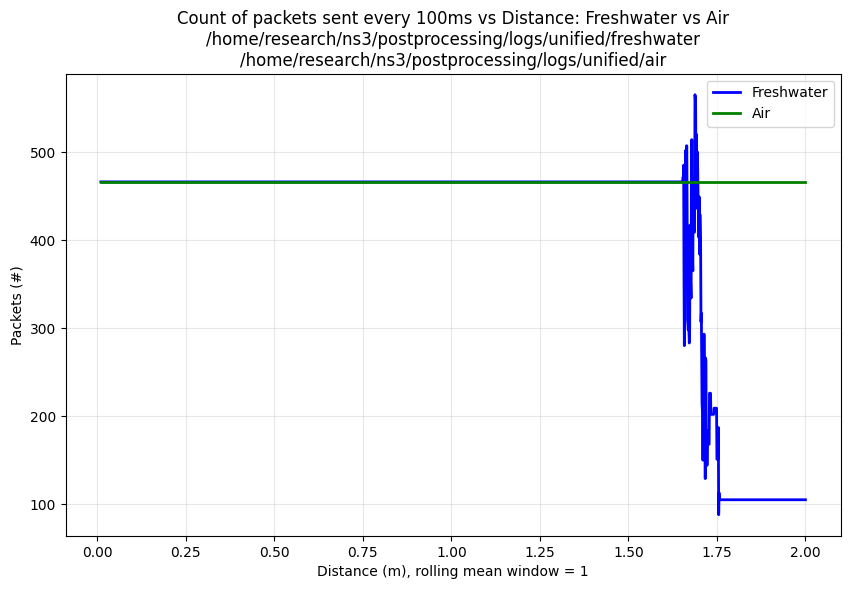

In [12]:
plt.figure(figsize=(10, 6))

# Plot rolling averages as solid lines
plt.plot(phy_tx_begin_freshwater_distance['Distance'], (phy_tx_begin_freshwater_distance['PacketCount']).rolling(window=1, min_periods=1).mean(), 
         label='Freshwater', color='blue', linewidth=2)
plt.plot(phy_tx_begin_air_distance['Distance'], (phy_tx_begin_air_distance['PacketCount']).rolling(window=1, min_periods=1).mean(), 
         label='Air', color='green', linewidth=2)

plt.xlabel('Distance (m), rolling mean window = 1')
plt.ylabel('Packets (#)')
plt.title(f'Count of packets sent every 100ms vs Distance: Freshwater vs Air\n{scenario_folder_freshwater}\n{scenario_folder_air}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()